In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [23]:
REPO_ROOT = Path("/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection")

SOURCE_SPECS = [
    {
        "results_root": REPO_ROOT / "results/occlusion/bgmm_generated_size16_both_models/source_resnet50_geirhos_tl/size_32",
        "generated_root": REPO_ROOT / "data/cases/generated_from_best_occluders",
        "model_type": "resnet50_geirhos_tl",
        "prefix": "shape",
    },
    {
        "results_root": REPO_ROOT / "results/occlusion/bgmm_generated_size16_both_models/source_resnet50_tl_20250829/size_32",
        "generated_root": REPO_ROOT / "data/cases/generated_from_best_occluders",
        "model_type": "resnet50_tl_20250829",
        "prefix": "texture",
    },
]

OUTPUT_DIR = REPO_ROOT / "results/occlusion/representative_shape_plots_size32"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_CSV = OUTPUT_DIR / "representative_shape_plots_manifest.csv"

OCCLUDER_SIZE = 32

# choose which member inside the top-1 cluster to plot
# 0 means the first listed member
TOP1_MEMBER_POSITION = 0

print("OUTPUT_DIR:", OUTPUT_DIR)
print("MANIFEST_CSV:", MANIFEST_CSV)

for spec in SOURCE_SPECS:
    print(spec["results_root"], "exists:", spec["results_root"].exists())

OUTPUT_DIR: /home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/representative_shape_plots_size32
MANIFEST_CSV: /home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/representative_shape_plots_size32/representative_shape_plots_manifest.csv
/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/bgmm_generated_size16_both_models/source_resnet50_geirhos_tl/size_32 exists: True
/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/bgmm_generated_size16_both_models/source_resnet50_tl_20250829/size_32 exists: True


In [24]:
def read_jsonl_rows(path: Path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def polygon_to_xy(poly, drop_duplicate_endpoint=True):
    xy = np.asarray(poly, dtype=float)
    if drop_duplicate_endpoint and len(xy) >= 2 and np.allclose(xy[0], xy[-1]):
        xy = xy[:-1]
    return xy


def close_xy_if_needed(xy, tol=1e-8):
    xy = np.asarray(xy, dtype=float)
    if len(xy) == 0:
        return xy
    if np.linalg.norm(xy[0] - xy[-1]) <= tol:
        return xy
    return np.vstack([xy, xy[0]])


def signed_area(xy):
    xy = np.asarray(xy, dtype=float)
    if len(xy) < 3:
        return 0.0
    if not np.allclose(xy[0], xy[-1]):
        xy = np.vstack([xy, xy[0]])
    x = xy[:, 0]
    y = xy[:, 1]
    return 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])


def ensure_ccw(xy):
    xy = np.asarray(xy, dtype=float)
    if signed_area(xy) < 0:
        return xy[::-1].copy()
    return xy.copy()

In [25]:
def get_shapes_npz_path(case_id: str, model_type: str, generated_root: Path, occluder_size=32):
    return (
        generated_root
        / case_id
        / model_type
        / f"size_{int(occluder_size)}"
        / "generated"
        / "shapes_xy.npz"
    )


def get_occluder_config_path(case_id: str, model_type: str, generated_root: Path, occluder_size=32):
    return (
        generated_root
        / case_id
        / model_type
        / f"size_{int(occluder_size)}"
        / "generated"
        / "source_occluder_config.json"
    )

In [26]:
def get_top1_selected_member(top10_jsonl_path: Path, member_position: int = 0):
    rows = read_jsonl_rows(top10_jsonl_path)
    if len(rows) == 0:
        raise ValueError(f"No rows found in {top10_jsonl_path}")

    top1 = None
    for row in rows:
        if int(row["cluster_rank"]) == 1:
            top1 = row
            break

    if top1 is None:
        raise ValueError(f"No cluster_rank=1 entry found in {top10_jsonl_path}")

    shapes = top1.get("shapes", [])
    if len(shapes) == 0:
        raise ValueError(f"Top-1 cluster has no shapes in {top10_jsonl_path}")

    if member_position >= len(shapes):
        raise IndexError(
            f"Requested member_position={member_position}, but top-1 cluster only has {len(shapes)} members"
        )

    selected = shapes[member_position]

    return {
        "cluster_rank": int(top1["cluster_rank"]),
        "target_k": int(top1["k"]),
        "case_id": top1["case_id"],
        "selected_member_position": int(member_position),
        "global_index": int(selected["global_index"]),
        "eligible_row": int(selected["eligible_row"]),
        "resp": float(selected["resp"]),
        "n_shapes_in_cluster": int(len(shapes)),
    }

In [27]:
def load_occluder_xy_from_config(config_path: Path, base_grid: float):
    with open(config_path, "r", encoding="utf-8") as f:
        cfg = json.load(f)

    x0_norm = float(cfg["x0_norm"])
    y0_norm = float(cfg["y0_norm"])
    x1_norm = float(cfg["x1_norm"])
    y1_norm = float(cfg["y1_norm"])

    occ_xy = np.array([
        [x0_norm, y0_norm],
        [x1_norm, y0_norm],
        [x1_norm, y1_norm],
        [x0_norm, y1_norm],
    ], dtype=float)

    occ_xy = occ_xy * float(base_grid)
    occ_xy = ensure_ccw(occ_xy)
    occ_xy = close_xy_if_needed(occ_xy)
    return occ_xy

In [28]:
def plot_case_representative(case_dir: Path, spec: dict, output_dir: Path, member_position: int = 0):
    case_id = case_dir.name
    top10_jsonl_path = case_dir / "top10_clusters.jsonl"

    if not top10_jsonl_path.exists():
        raise FileNotFoundError(f"Missing top10_clusters.jsonl: {top10_jsonl_path}")

    selected_meta = get_top1_selected_member(top10_jsonl_path, member_position=member_position)

    shapes_npz_path = get_shapes_npz_path(
        case_id=case_id,
        model_type=spec["model_type"],
        generated_root=spec["generated_root"],
        occluder_size=OCCLUDER_SIZE,
    )

    occluder_config_path = get_occluder_config_path(
        case_id=case_id,
        model_type=spec["model_type"],
        generated_root=spec["generated_root"],
        occluder_size=OCCLUDER_SIZE,
    )

    if not shapes_npz_path.exists():
        raise FileNotFoundError(f"Missing shapes_xy.npz: {shapes_npz_path}")

    if not occluder_config_path.exists():
        raise FileNotFoundError(f"Missing source_occluder_config.json: {occluder_config_path}")

    npz = np.load(shapes_npz_path, allow_pickle=True)
    polygons = npz["polygons"]
    base_grid = float(np.asarray(npz["base_grid"]).squeeze())

    gidx = selected_meta["global_index"]
    if gidx < 0 or gidx >= len(polygons):
        raise IndexError(
            f"global_index={gidx} out of bounds for polygons array of length {len(polygons)}"
        )

    # build shape geometry anew from the stored polygon
    shape_xy = polygon_to_xy(polygons[gidx], drop_duplicate_endpoint=True)
    shape_xy = ensure_ccw(shape_xy)
    shape_xy = close_xy_if_needed(shape_xy)

    # build occluder geometry anew from config
    occ_xy = load_occluder_xy_from_config(occluder_config_path, base_grid=base_grid)

    out_png = output_dir / f"{spec['prefix']}_{case_id}_representative.png"

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.plot(
        shape_xy[:, 0],
        shape_xy[:, 1],
        lw=2.5,
        color="black",
    )

    ax.plot(
        occ_xy[:, 0],
        occ_xy[:, 1],
        "--",
        lw=1.5,
        color="0.5",
    )

    ax.set_aspect("equal")
    ax.axis("off")

    all_xy = np.vstack([shape_xy, occ_xy])
    xmin, ymin = all_xy.min(axis=0)
    xmax, ymax = all_xy.max(axis=0)

    dx = xmax - xmin
    dy = ymax - ymin
    pad_x = 0.03 * dx if dx > 0 else 1.0
    pad_y = 0.03 * dy if dy > 0 else 1.0

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    fig.savefig(
        out_png,
        dpi=300,
        bbox_inches="tight",
        pad_inches=0,
        facecolor="white",
        edgecolor="none",
    )
    plt.close(fig)

    return {
        "case_id": case_id,
        "prefix": spec["prefix"],
        "model_type": spec["model_type"],
        "cluster_rank": selected_meta["cluster_rank"],
        "target_k": selected_meta["target_k"],
        "selected_member_position": selected_meta["selected_member_position"],
        "global_index": selected_meta["global_index"],
        "eligible_row": selected_meta["eligible_row"],
        "resp": selected_meta["resp"],
        "n_shapes_in_cluster": selected_meta["n_shapes_in_cluster"],
        "base_grid": base_grid,
        "source_top10_jsonl": str(top10_jsonl_path),
        "source_shapes_npz": str(shapes_npz_path),
        "source_occluder_config": str(occluder_config_path),
        "output_png": str(out_png),
        "status": "ok",
        "error": "",
    }

In [29]:
test_spec = SOURCE_SPECS[0]
test_case_dir = test_spec["results_root"] / "ns_cow_202"

test_row = plot_case_representative(
    case_dir=test_case_dir,
    spec=test_spec,
    output_dir=OUTPUT_DIR,
    member_position=TOP1_MEMBER_POSITION,
)

pd.DataFrame([test_row])

,case_id,prefix,model_type,cluster_rank,target_k,selected_member_position,global_index,eligible_row,resp,n_shapes_in_cluster,base_grid,source_top10_jsonl,source_shapes_npz,source_occluder_config,output_png,status,error
0,ns_cow_202,shape,resnet50_geirhos_tl,1,72,0,6769,6769,1.0,25,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,


In [30]:
manifest_rows = []

for spec in SOURCE_SPECS:
    case_dirs = sorted([p for p in spec["results_root"].iterdir() if p.is_dir()])
    print(f"\nFound {len(case_dirs)} case folders under:\n{spec['results_root']}")

    for i, case_dir in enumerate(case_dirs, start=1):
        case_id = case_dir.name
        print(f"[{i:03d}/{len(case_dirs):03d}] Processing {spec['prefix']} | {case_id}")

        try:
            row = plot_case_representative(
                case_dir=case_dir,
                spec=spec,
                output_dir=OUTPUT_DIR,
                member_position=TOP1_MEMBER_POSITION,
            )
            manifest_rows.append(row)
            print(
                f"  ok | gidx={row['global_index']} | "
                f"cluster size={row['n_shapes_in_cluster']} | resp={row['resp']:.6f}"
            )
        except Exception as e:
            manifest_rows.append({
                "case_id": case_id,
                "prefix": spec["prefix"],
                "model_type": spec["model_type"],
                "cluster_rank": np.nan,
                "target_k": np.nan,
                "selected_member_position": TOP1_MEMBER_POSITION,
                "global_index": np.nan,
                "eligible_row": np.nan,
                "resp": np.nan,
                "n_shapes_in_cluster": np.nan,
                "base_grid": np.nan,
                "source_top10_jsonl": str(case_dir / "top10_clusters.jsonl"),
                "source_shapes_npz": "",
                "source_occluder_config": "",
                "output_png": "",
                "status": "failed",
                "error": str(e),
            })
            print("  failed:", e)


Found 40 case folders under:
/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/bgmm_generated_size16_both_models/source_resnet50_geirhos_tl/size_32
[001/040] Processing shape | ns_cow_202
  ok | gidx=6769 | cluster size=25 | resp=1.000000
[002/040] Processing shape | ns_cow_205
  ok | gidx=6695 | cluster size=25 | resp=0.999999
[003/040] Processing shape | ns_cow_350
  ok | gidx=9106 | cluster size=25 | resp=1.000000
[004/040] Processing shape | ns_cow_510
  ok | gidx=4244 | cluster size=25 | resp=1.000000
[005/040] Processing shape | ns_cow_780
  ok | gidx=6178 | cluster size=25 | resp=1.000000
[006/040] Processing shape | ns_dog_105
  ok | gidx=5285 | cluster size=25 | resp=0.999998
[007/040] Processing shape | ns_dog_214
  ok | gidx=5015 | cluster size=25 | resp=0.999684
[008/040] Processing shape | ns_dog_350
  ok | gidx=4004 | cluster size=25 | resp=1.000000
[009/040] Processing shape | ns_dog_69
  ok | gidx=4870 | cluster size=25 | resp=1.000000
[

In [31]:
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(MANIFEST_CSV, index=False)

print("Done.")
print("Manifest saved to:")
print(MANIFEST_CSV)

display(manifest_df)

Done.
Manifest saved to:
/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/representative_shape_plots_size32/representative_shape_plots_manifest.csv


,case_id,prefix,model_type,cluster_rank,target_k,selected_member_position,global_index,eligible_row,resp,n_shapes_in_cluster,base_grid,source_top10_jsonl,source_shapes_npz,source_occluder_config,output_png,status,error
0,ns_cow_202,shape,resnet50_geirhos_tl,1.0,72.0,0,6769.0,6769.0,1.000000,25.0,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,
1,ns_cow_205,shape,resnet50_geirhos_tl,1.0,70.0,0,6695.0,6695.0,0.999999,25.0,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,
2,ns_cow_350,shape,resnet50_geirhos_tl,1.0,56.0,0,9106.0,9106.0,1.000000,25.0,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,
3,ns_cow_510,shape,resnet50_geirhos_tl,1.0,36.0,0,4244.0,4244.0,1.000000,25.0,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,
4,ns_cow_780,shape,resnet50_geirhos_tl,1.0,51.0,0,6178.0,6178.0,1.000000,25.0,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,s_fish_700,texture,resnet50_tl_20250829,1.0,4.0,0,5210.0,5210.0,0.992328,25.0,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,
76,s_fish_800,texture,resnet50_tl_20250829,1.0,30.0,0,9460.0,9460.0,0.516644,25.0,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,
77,s_fish_900,texture,resnet50_tl_20250829,1.0,4.0,0,22.0,22.0,0.994004,25.0,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,
78,s_oyster_350,texture,resnet50_tl_20250829,1.0,0.0,0,7315.0,7315.0,0.100369,25.0,256.0,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,/home/hschatzle/data/storage-occ-v2/repos/mont...,ok,


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.offsetbox import AnnotationBbox, DrawingArea
from matplotlib.patches import Rectangle

In [34]:
CASE_JSONL = Path(
    "/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/data/cases/occlusion/ns_monkey_88/generated/ns_monkey_88.jsonl"
)

with open(CASE_JSONL, "r", encoding="utf-8") as f:
    row = json.loads(next(f))

shape_xy = np.asarray(row["shape_contour_xy"], dtype=float)
invert_yaxis = bool(row.get("plotting", {}).get("invert_yaxis", True))

print("coord_system:", row["coord_system"])

coord_system: normalized_contour_space


In [35]:
def close_xy_if_needed(xy, tol=1e-8):
    xy = np.asarray(xy, dtype=float)
    if np.linalg.norm(xy[0] - xy[-1]) <= tol:
        return xy
    return np.vstack([xy, xy[0]])


def signed_area(xy):
    xy = np.asarray(xy, dtype=float)
    if not np.allclose(xy[0], xy[-1]):
        xy = np.vstack([xy, xy[0]])
    x = xy[:, 0]
    y = xy[:, 1]
    return 0.5 * np.sum(x[:-1] * y[1:] - x[1:] * y[:-1])


def ensure_ccw(xy):
    xy = np.asarray(xy, dtype=float)
    return xy[::-1].copy() if signed_area(xy) < 0 else xy.copy()


def cumulative_arc_lengths(xy, closed=True):
    xy = np.asarray(xy, dtype=float)
    if closed:
        xy = close_xy_if_needed(xy)
    seg = np.diff(xy, axis=0)
    seglen = np.sqrt((seg ** 2).sum(axis=1))
    cum = np.concatenate([[0.0], np.cumsum(seglen)])
    return xy, seglen, cum


def sample_point_on_closed_contour_by_fraction(xy, frac):
    xy_use, seglen, cum = cumulative_arc_lengths(xy, closed=True)
    total = cum[-1]
    target = frac * total
    idx = np.searchsorted(cum, target, side="right") - 1
    idx = min(max(idx, 0), len(seglen) - 1)

    a = xy_use[idx]
    b = xy_use[idx + 1]
    local = target - cum[idx]
    t = 0.0 if seglen[idx] < 1e-12 else local / seglen[idx]
    p = a + t * (b - a)
    return p, idx, t

In [61]:
shape_xy = ensure_ccw(shape_xy)
shape_xy_closed = close_xy_if_needed(shape_xy)

PLACEMENT_FRACTION = 0.5
OCCLUDER_SIZE_PX = 64

anchor_xy, seg_idx, seg_t = sample_point_on_closed_contour_by_fraction(shape_xy, PLACEMENT_FRACTION)

print("Anchor:", anchor_xy)
print("Segment index:", seg_idx)
print("Occluder size in rendered pixels:", OCCLUDER_SIZE_PX)

Anchor: [0.67667702 0.58243465]
Segment index: 150
Occluder size in rendered pixels: 64


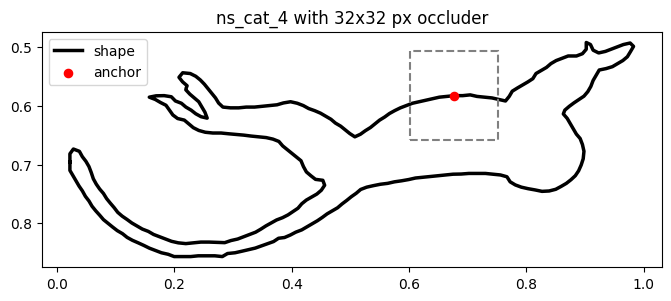

In [62]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

ax.plot(
    shape_xy_closed[:, 0],
    shape_xy_closed[:, 1],
    lw=2.5,
    color="black",
    label="shape",
)

ax.scatter(
    [anchor_xy[0]],
    [anchor_xy[1]],
    s=35,
    color="red",
    zorder=6,
    label="anchor",
)

# 32 x 32 pixel occluder in display space
da = DrawingArea(OCCLUDER_SIZE_PX, OCCLUDER_SIZE_PX, 0, 0)
rect = Rectangle(
    (0, 0),
    OCCLUDER_SIZE_PX,
    OCCLUDER_SIZE_PX,
    fill=False,
    linestyle="--",
    linewidth=1.5,
    edgecolor="0.5",
)
da.add_artist(rect)

ab = AnnotationBbox(
    da,
    anchor_xy,
    xycoords="data",
    frameon=False,
    box_alignment=(0.5, 0.5),
    zorder=5,
)
ax.add_artist(ab)

ax.set_aspect("equal")
if invert_yaxis:
    ax.invert_yaxis()
ax.legend()
ax.set_title("ns_cat_4 with 32x32 px occluder")
plt.show()

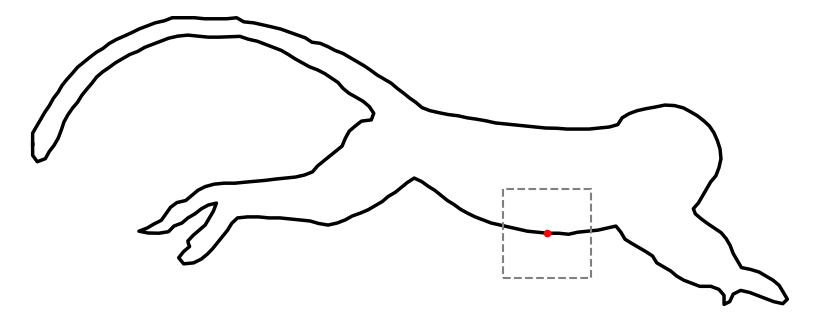

In [63]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

ax.plot(shape_xy_closed[:, 0], shape_xy_closed[:, 1], lw=2.5, color="black")
ax.scatter([anchor_xy[0]], [anchor_xy[1]], s=20, color="red", zorder=6)

da = DrawingArea(OCCLUDER_SIZE_PX, OCCLUDER_SIZE_PX, 0, 0)
rect = Rectangle(
    (0, 0),
    OCCLUDER_SIZE_PX,
    OCCLUDER_SIZE_PX,
    fill=False,
    linestyle="--",
    linewidth=1.5,
    edgecolor="0.5",
)
da.add_artist(rect)

ab = AnnotationBbox(
    da,
    anchor_xy,
    xycoords="data",
    frameon=False,
    box_alignment=(0.5, 0.5),
    zorder=5,
)
ax.add_artist(ab)

ax.set_aspect("equal")
ax.axis("off")
if invert_yaxis:
    ax.invert_yaxis()

xmin, ymin = shape_xy_closed.min(axis=0)
xmax, ymax = shape_xy_closed.max(axis=0)
dx = xmax - xmin
dy = ymax - ymin
pad_x = 0.03 * dx
pad_y = 0.03 * dy

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
plt.show()

In [64]:
OUT_PNG = CASE_JSONL.parent / "ns_cat_4_32px_occluder_true_pixels.png"

fig, ax = plt.subplots(figsize=(8, 8), dpi=100)

ax.plot(shape_xy_closed[:, 0], shape_xy_closed[:, 1], lw=2.5, color="black")

da = DrawingArea(OCCLUDER_SIZE_PX, OCCLUDER_SIZE_PX, 0, 0)
rect = Rectangle(
    (0, 0),
    OCCLUDER_SIZE_PX,
    OCCLUDER_SIZE_PX,
    fill=False,
    linestyle="--",
    linewidth=1.5,
    edgecolor="0.5",
)
da.add_artist(rect)

ab = AnnotationBbox(
    da,
    anchor_xy,
    xycoords="data",
    frameon=False,
    box_alignment=(0.5, 0.5),
    zorder=5,
)
ax.add_artist(ab)

ax.set_aspect("equal")
ax.axis("off")
if invert_yaxis:
    ax.invert_yaxis()

xmin, ymin = shape_xy_closed.min(axis=0)
xmax, ymax = shape_xy_closed.max(axis=0)
dx = xmax - xmin
dy = ymax - ymin
pad_x = 0.03 * dx
pad_y = 0.03 * dy

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
fig.savefig(
    OUT_PNG,
    dpi=100,
    bbox_inches="tight",
    pad_inches=0,
    facecolor="white",
    edgecolor="none",
)
plt.close(fig)

print("Saved to:", OUT_PNG)

Saved to: /home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/data/cases/occlusion/ns_monkey_88/generated/ns_cat_4_32px_occluder_true_pixels.png


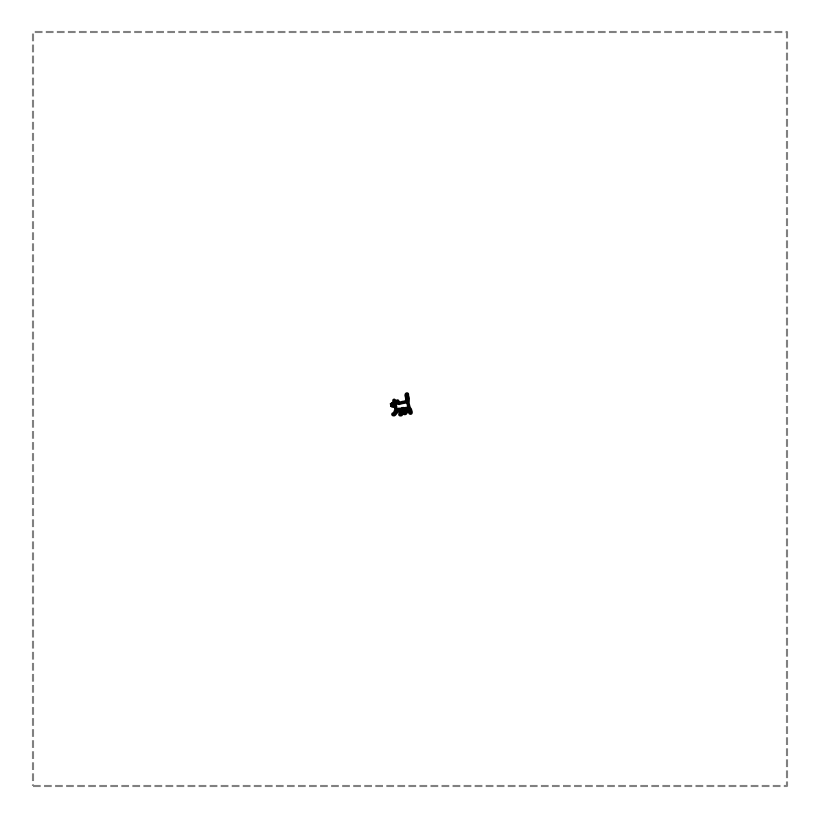

In [ ]:
# preview multiple placements, all with true 32x32 rendered pixels
fractions = [0.10, 0.25, 0.40, 0.55, 0.70, 0.85]

fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=100)

for ax, frac in zip(axes.ravel(), fractions):
    anchor_xy, _, _ = sample_point_on_closed_contour_by_fraction(shape_xy, frac)

    ax.plot(shape_xy_closed[:, 0], shape_xy_closed[:, 1], lw=2.0, color="black")
    ax.scatter([anchor_xy[0]], [anchor_xy[1]], s=18, color="red", zorder=6)

    da = DrawingArea(OCCLUDER_SIZE_PX, OCCLUDER_SIZE_PX, 0, 0)
    rect = Rectangle(
        (0, 0),
        OCCLUDER_SIZE_PX,
        OCCLUDER_SIZE_PX,
        fill=False,
        linestyle="--",
        linewidth=1.2,
        edgecolor="0.5",
    )
    da.add_artist(rect)

    ab = AnnotationBbox(
        da,
        anchor_xy,
        xycoords="data",
        frameon=False,
        box_alignment=(0.5, 0.5),
        zorder=5,
    )
    ax.add_artist(ab)

    ax.set_aspect("equal")
    ax.axis("off")
    if invert_yaxis:
        ax.invert_yaxis()
    ax.set_title(f"frac={frac:.2f}")

plt.tight_layout()
plt.show()